# Hyperparameter grid search — centroid loss v2 — Norman 2019 (100 % gamma 1.1)

Anchored at the best setting from centroid grid v1 (`alpha_mmd=20`, all else original),
this notebook explores finer variations with **centroid loss** (`use_centroid_loss=True`)
and runs **all three models** for every setting:

- **CMVAE-full**: `use_tf_only=False, use_GRN_priors=False, z_dim=None`
- **CMVAE-comp**: `use_tf_only=False, use_GRN_priors=False, z_dim=n_eig`  (same z as gCRL-VAE)
- **gCRL-VAE**:   `use_tf_only=True,  use_GRN_priors=True,  z_dim=None`

Note: `lambda_mcc` is ignored by both CMVAE variants (zeroed in the trainer when
`use_GRN_priors=False`); only gCRL-VAE is affected by it.

| # | Name | Change from anchor | Rationale |
|---|---|---|---|
| 1 | `mmd20` | — | Carry-over of centroid v1 best; reference for this grid |
| 2 | `mmd30` | alpha_mmd=30 | v1 only went to 20; centroid loss may tolerate more |
| 3 | `mmd40` | alpha_mmd=40 | Push further to find saturation point |
| 4 | `mmd20_kld01` | beta_kld=0.1 | kld05 hurt in v1, but very low KLD helped CMVAE-full in MMD v2 |
| 5 | `mmd30_kld01` | alpha_mmd=30, beta_kld=0.1 | Combine higher MMD with minimal KLD |
| 6 | `mmd20_lr3e3` | lr=3e-3 | lr=1e-4 hurt; does slightly higher LR than default help? |
| 7 | `mmd20_epochs150` | epochs=150 | slow_ramp (200) hurt badly; sweet spot slightly above 100? |
| 8 | `mmd20_mcc5` | lambda_mcc=5.0 | No effect with MMD; worth checking with centroid's different gradient |
| 9 | `mmd20_sparse1e4` | lambda_sparse=1e-4 | sparse01 hurt slightly; does less sparse than default help? |
| 10 | `mmd30_kld01_mcc5` | alpha_mmd=30, beta_kld=0.1, lambda_mcc=5.0 | Best knobs combined with stronger MCC for gCRL-VAE |


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, "../../src")

import warnings
warnings.filterwarnings("ignore")

import os
import json
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

from gcrl.grn.eigengenes import compute_eigengenes
from gcrl.training.train_gcrl_vae import VAEConfig, train_gcrl_vae
from gcrl.evaluation.prediction_eval import evaluate_predictions

In [3]:
# Control panel
_ctrl_labels = ["unperturbed", "control", "ctrl"]

DATA_PATH = "../../data/real/Norman2019/Norman2019_processed_100pct_gamma1p1.h5ad"
BASE_DIR  = "../../results/real/Norman2019/centroid_grid_v2_trial"  # TRIAL RUN

## 1. Load data and compute eigengenes

In [4]:
adata = ad.read_h5ad(DATA_PATH)
print(f"Loaded: {adata.shape[0]} cells × {adata.shape[1]} genes")

compute_eigengenes(
    adata,
    community_col="community",
    reference_query='intervention == "unperturbed"',
    mode="all_cells",
    method="PC",
    seed=42,
)
eig   = adata.obsm["X_comm_eig"]
n_eig = eig.shape[1]
print(f"Eigengene matrix: {eig.shape}  (n_cells × n_communities+1)")

Loaded: 35048 cells × 2703 genes


Eigengene matrix: (35048, 8)  (n_cells × n_communities+1)


## 2. Define configurations

The anchor (`_base`) is the best setting from centroid grid v1: `alpha_mmd=20`.
All other hyperparameters are kept at the original discrepancy-VAE defaults.
`use_centroid_loss=True` is fixed for all runs.

In [5]:
# Anchor: best setting from centroid grid v1
_base = dict(
    use_centroid_loss = True,
    alpha_mmd_max     = 20.0,
    beta_kld_max      = 2.0,
    lambda_sparse     = 1e-3,
    lambda_mcc        = 1.0,   # active only for gCRL-VAE; zeroed for CMVAE variants
    lr                = 1e-3,
    batch_size        = 32,
    epochs            = 3,     # TRIAL RUN: normally 100
    seed              = 0,
)

SETTINGS = [
    # (name,                   overrides)
    ("01_mmd20",               {}),
    ("02_mmd30",               dict(alpha_mmd_max=30.0)),
    ("03_mmd40",               dict(alpha_mmd_max=40.0)),
    ("04_mmd20_kld01",         dict(beta_kld_max=0.1)),
    ("05_mmd30_kld01",         dict(alpha_mmd_max=30.0, beta_kld_max=0.1)),
    ("06_mmd20_lr3e3",         dict(lr=3e-3)),
    ("07_mmd20_epochs150",     dict(epochs=3)),    # TRIAL RUN: normally epochs=150
    ("08_mmd20_mcc5",          dict(lambda_mcc=5.0)),
    ("09_mmd20_sparse1e4",     dict(lambda_sparse=1e-4)),
    ("10_mmd30_kld01_mcc5",    dict(alpha_mmd_max=30.0, beta_kld_max=0.1, lambda_mcc=5.0)),
]

# Sub-models to train for every setting
SUBMODELS = [
    ("cmvae_full", dict(use_tf_only=False, use_GRN_priors=False, z_dim=None)),
    ("cmvae_comp", dict(use_tf_only=False, use_GRN_priors=False, z_dim=n_eig)),
    ("gcrl_vae",   dict(use_tf_only=True,  use_GRN_priors=True,  z_dim=None)),
]

print(f"{len(SETTINGS)} settings × {len(SUBMODELS)} models = {len(SETTINGS)*len(SUBMODELS)} runs")

10 settings × 3 models = 30 runs


## 3. Train all configurations

Results are saved after each (setting, model) pair. On re-run, already-completed
runs are skipped automatically.

In [6]:
models    = {}
histories = {}

for name, overrides in SETTINGS:
    for sub_name, sub_kwargs in SUBMODELS:
        key       = (name, sub_name)
        out_dir   = f"{BASE_DIR}/{name}/{sub_name}"
        hist_path = f"{out_dir}/training_history.json"

        # Skip if already completed
        if os.path.exists(hist_path):
            print(f"Skipping {name}/{sub_name}  (already done)")
            with open(hist_path) as f:
                histories[key] = pd.DataFrame(json.load(f))
            models[key] = None
            continue

        print(f"\n{'='*55}")
        print(f"Training: {name} / {sub_name}")
        print(f"{'='*55}")
        cfg_kwargs = {**_base, **overrides, **sub_kwargs}
        cfg = VAEConfig(outdir=out_dir, **cfg_kwargs)
        model, history = train_gcrl_vae(adata, cfg, eigengenes_key="X_comm_eig")
        models[key]    = model
        histories[key] = pd.DataFrame(history)

        # Save history immediately after this run
        os.makedirs(out_dir, exist_ok=True)
        with open(hist_path, "w") as f:
            json.dump(histories[key].to_dict(orient="list"), f)
        print(f"  History saved → {hist_path}")

print("\nAll configurations trained.")


Training: 01_mmd20 / cmvae_full
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/3 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/centroid_grid_v2_trial/01_mmd20/cmvae_full/
  History saved → ../../results/real/Norman2019/centroid_grid_v2_trial/01_mmd20/cmvae_full/training_history.json

Training: 01_mmd20 / cmvae_comp
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/3 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/centroid_grid_v2_trial/01_mmd20/cmvae_comp/
  History saved → ../../results/real/Norman2019/centroid_grid_v2_trial/01_mmd20/cmvae_comp/training_history.json

Training: 01_mmd20 / gcrl_vae
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


...

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/centroid_grid_v2_trial/10_mmd30_kld01_mcc5/cmvae_full/
  History saved → ../../results/real/Norman2019/centroid_grid_v2_trial/10_mmd30_kld01_mcc5/cmvae_full/training_history.json

Training: 10_mmd30_kld01_mcc5 / cmvae_comp
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/3 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/centroid_grid_v2_trial/10_mmd30_kld01_mcc5/cmvae_comp/
  History saved → ../../results/real/Norman2019/centroid_grid_v2_trial/10_mmd30_kld01_mcc5/cmvae_comp/training_history.json

Training: 10_mmd30_kld01_mcc5 / gcrl_vae
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/3 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/centroid_grid_v2_trial/10_mmd30_kld01_mcc5/gcrl_vae/
  History saved → ../../results/real/Norman2019/centroid_grid_v2_trial/10_mmd30_kld01_mcc5/gcrl_vae/training_history.json

All configurations trained.


## 4. Predict and evaluate

In [7]:
_predict_kwargs = dict(
    set_key          = "set",
    intervention_key = "intervention",
    cell_type_key    = "cell_type",
    control_labels   = tuple(_ctrl_labels),
    seed             = 42,
)

metrics = {}

for name, _ in SETTINGS:
    for sub_name, _ in SUBMODELS:
        key      = (name, sub_name)
        out_dir  = f"{BASE_DIR}/{name}/{sub_name}"
        csv_path = f"{out_dir}/prediction_metrics.csv"

        # Reload from disk if already evaluated
        if os.path.exists(csv_path):
            print(f"Skipping eval {name}/{sub_name}  (already done)")
            metrics[key] = pd.read_csv(csv_path)
            continue

        preds = models[key].predict(adata, **_predict_kwargs)
        metrics[key] = evaluate_predictions(
            adata          = adata,
            preds          = preds,
            output_dir     = out_dir,
            control_labels = tuple(_ctrl_labels),
        )
        cd = metrics[key].query("metric_name == 'centroid_distance' and method == 'actual'")["metric_value"].median()
        wc = metrics[key].query("metric_name == 'centroid_distance' and method == 'worst_case'")["metric_value"].median()
        print(f"{name}/{sub_name:<12}  actual={cd:.4f}  worst_case={wc:.4f}")

print("\nAll evaluations complete.")

01_mmd20/cmvae_full    actual=5.8915  worst_case=5.4667


01_mmd20/cmvae_comp    actual=5.5055  worst_case=5.4667


01_mmd20/gcrl_vae      actual=5.4813  worst_case=5.4667


02_mmd30/cmvae_full    actual=5.8915  worst_case=5.4667


02_mmd30/cmvae_comp    actual=5.5055  worst_case=5.4667


...

09_mmd20_sparse1e4/cmvae_comp    actual=5.5055  worst_case=5.4667


09_mmd20_sparse1e4/gcrl_vae      actual=5.4838  worst_case=5.4667


10_mmd30_kld01_mcc5/cmvae_full    actual=5.8915  worst_case=5.4667


10_mmd30_kld01_mcc5/cmvae_comp    actual=5.5055  worst_case=5.4667


10_mmd30_kld01_mcc5/gcrl_vae      actual=5.6098  worst_case=5.4667

All evaluations complete.


## 5. Training curves

Rows = sub-models, columns = loss components.

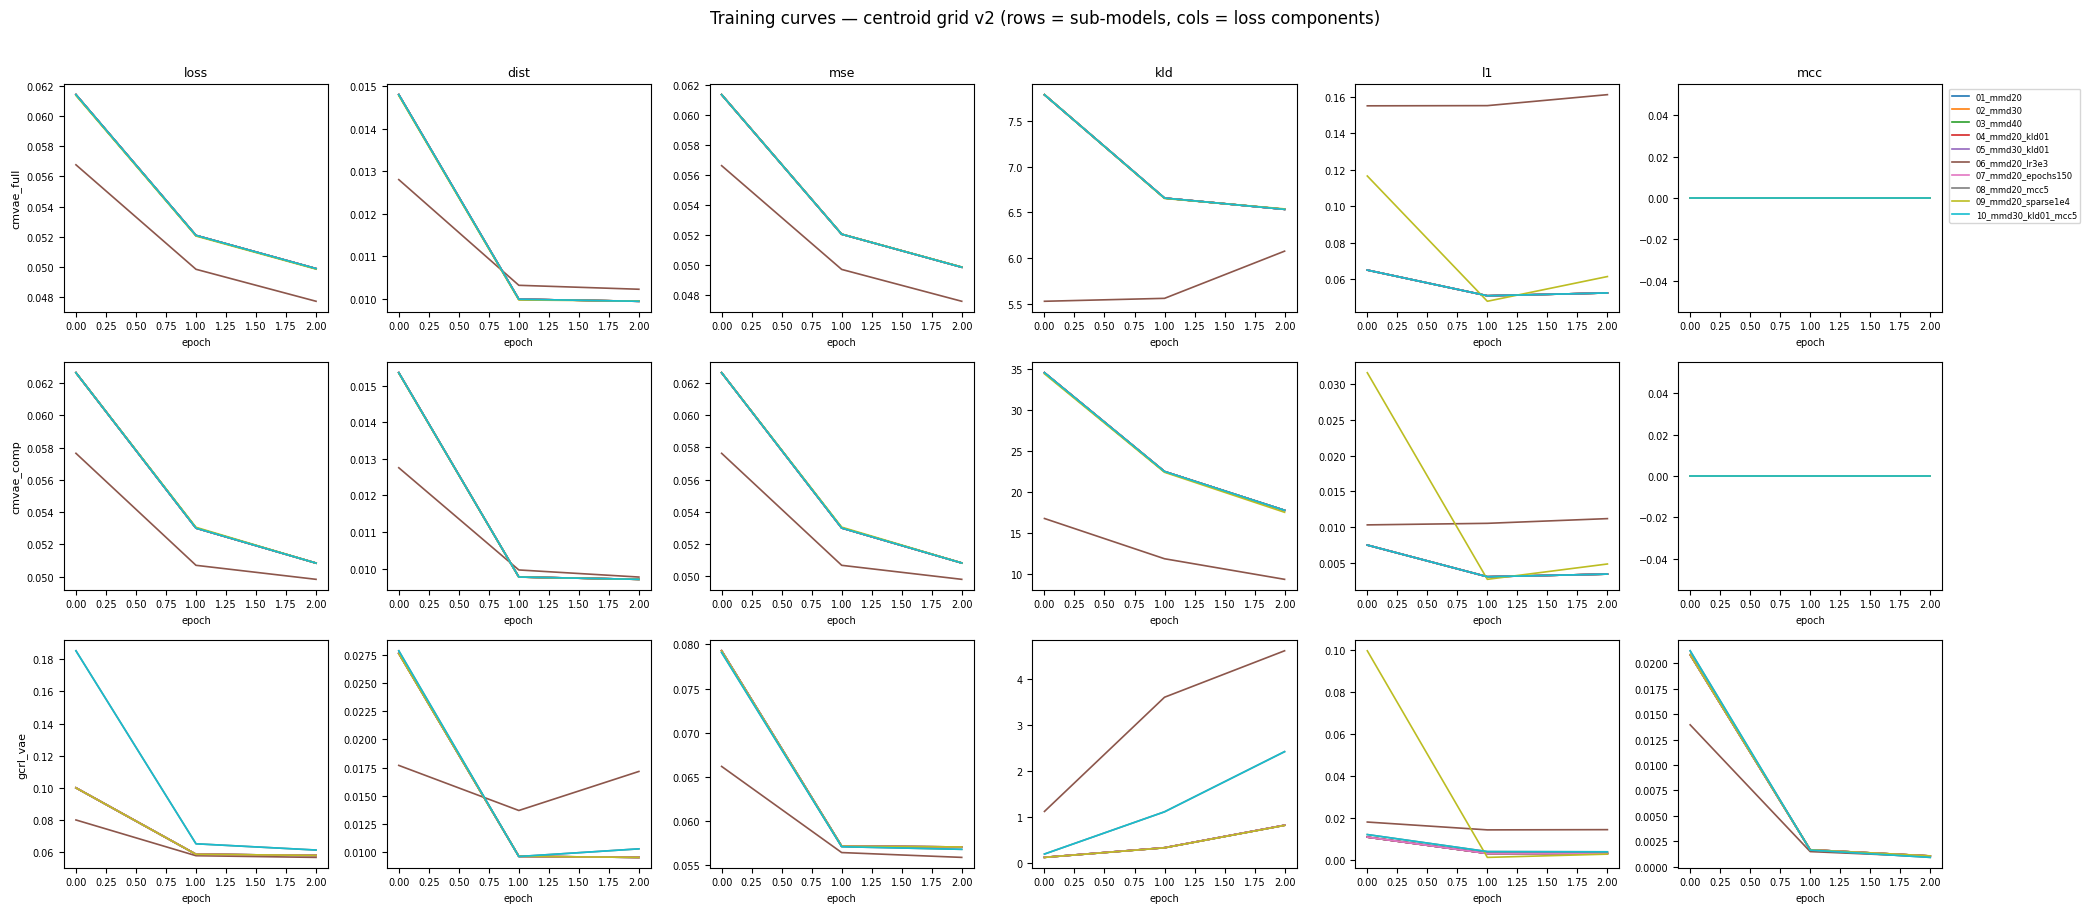

In [8]:
LOSS_COLS  = ["loss", "dist", "mse", "kld", "l1", "mcc"]
cmap       = plt.get_cmap("tab10")
set_styles = {name: cmap(i % 10) for i, (name, _) in enumerate(SETTINGS)}

n_sub  = len(SUBMODELS)
n_cols = len(LOSS_COLS)
fig, axes = plt.subplots(n_sub, n_cols, figsize=(3.5 * n_cols, 3 * n_sub), squeeze=False)

for row, (sub_name, _) in enumerate(SUBMODELS):
    for col, lc in enumerate(LOSS_COLS):
        ax = axes[row, col]
        for name, _ in SETTINGS:
            df = histories[(name, sub_name)]
            if lc in df.columns:
                ax.plot(df["epoch"], df[lc], label=name, color=set_styles[name], linewidth=1.2)
        if row == 0:
            ax.set_title(lc, fontsize=9)
        if col == 0:
            ax.set_ylabel(sub_name, fontsize=8)
        ax.set_xlabel("epoch", fontsize=7)
        ax.tick_params(labelsize=7)
        if row == 0 and col == n_cols - 1:
            ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("Training curves — centroid grid v2 (rows = sub-models, cols = loss components)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Performance summary table

In [9]:
rows = []
for name, _ in SETTINGS:
    for sub_name, _ in SUBMODELS:
        df = metrics[(name, sub_name)]
        for metric_name in ["centroid_distance", "rmse"]:
            for method in ["actual", "worst_case", "perfect_baseline"]:
                val = df.loc[
                    (df["metric_name"] == metric_name) & (df["method"] == method),
                    "metric_value"
                ].median()
                rows.append({
                    "setting": name,
                    "model":   sub_name,
                    "metric":  metric_name,
                    "method":  method,
                    "median":  val,
                })

summary = pd.DataFrame(rows)
pivot = summary.pivot_table(
    index=["setting", "model"],
    columns=["metric", "method"],
    values="median",
).round(4)
pivot = pivot.sort_values(("centroid_distance", "actual"))
print("Median metrics across all double-perturbation conditions (sorted by centroid_distance actual):")
pivot

Median metrics across all double-perturbation conditions (sorted by centroid_distance actual):


metric                         centroid_distance                              \
method                                    actual perfect_baseline worst_case   
setting             model                                                      
01_mmd20            gcrl_vae              5.4813           1.8756     5.4667   
02_mmd30            gcrl_vae              5.4813           1.8756     5.4667   
04_mmd20_kld01      gcrl_vae              5.4813           1.8756     5.4667   
03_mmd40            gcrl_vae              5.4813           1.8756     5.4667   
05_mmd30_kld01      gcrl_vae              5.4813           1.8756     5.4667   
07_mmd20_epochs150  gcrl_vae              5.4813           1.8756     5.4667   
09_mmd20_sparse1e4  gcrl_vae              5.4838           1.8756     5.4667   
03_mmd40            cmvae_comp            5.5055           1.8756     5.4667   
05_mmd30_kld01      cmvae_comp            5.5055           1.8756     5.4667   
04_mmd20_kld01      cmvae_comp            5.5055           1.8756     5.4667   
10_mmd30_kld01_mcc5 cmvae_comp            5.5055           1.8756     5.4667   
09_mmd20_sparse1e4  cmvae_comp            5.5055           1.8756     5.4667   
07_mmd20_epochs150  cmvae_comp            5.5055           1.8756     5.4667   
08_mmd20_mcc5       cmvae_comp            5.5055           1.8756     5.4667   
02_mmd30            cmvae_comp            5.5055           1.8756     5.4667   
01_mmd20            cmvae_comp            5.5055           1.8756     5.4667   
06_mmd20_lr3e3      cmvae_full            5.6032           1.8756     5.4667   
08_mmd20_mcc5       gcrl_vae              5.6098           1.8756     5.4667   
10_mmd30_kld01_mcc5 gcrl_vae              5.6098           1.8756     5.4667   
06_mmd20_lr3e3      cmvae_comp            5.6347           1.8756     5.4667   
09_mmd20_sparse1e4  cmvae_full            5.7387           1.8756     5.4667   
01_mmd20            cmvae_full            5.8915           1.8756     5.4667   
02_mmd30            cmvae_full            5.8915           1.8756     5.4667   
03_mmd40            cmvae_full            5.8915           1.8756     5.4667   
05_mmd30_kld01      cmvae_full            5.8915           1.8756     5.4667   
04_mmd20_kld01      cmvae_full            5.8915           1.8756     5.4667   
07_mmd20_epochs150  cmvae_full            5.8915           1.8756     5.4667   
08_mmd20_mcc5       cmvae_full            5.8915           1.8756     5.4667   
10_mmd30_kld01_mcc5 cmvae_full            5.8915           1.8756     5.4667   
06_mmd20_lr3e3      gcrl_vae              6.7956           1.8756     5.4667   

metric                            rmse                              
method                          actual perfect_baseline worst_case  
setting             model                                           
01_mmd20            gcrl_vae    0.1054           0.0361     0.1051  
02_mmd30            gcrl_vae    0.1054           0.0361     0.1051  
04_mmd20_kld01      gcrl_vae    0.1054           0.0361     0.1051  
03_mmd40            gcrl_vae    0.1054           0.0361     0.1051  
05_mmd30_kld01      gcrl_vae    0.1054           0.0361     0.1051  
07_mmd20_epochs150  gcrl_vae    0.1054           0.0361     0.1051  
09_mmd20_sparse1e4  gcrl_vae    0.1055           0.0361     0.1051  
03_mmd40            cmvae_comp  0.1059           0.0361     0.1051  
05_mmd30_kld01      cmvae_comp  0.1059           0.0361     0.1051  
04_mmd20_kld01      cmvae_comp  0.1059           0.0361     0.1051  
10_mmd30_kld01_mcc5 cmvae_comp  0.1059           0.0361     0.1051  
09_mmd20_sparse1e4  cmvae_comp  0.1059           0.0361     0.1051  
07_mmd20_epochs150  cmvae_comp  0.1059           0.0361     0.1051  
08_mmd20_mcc5       cmvae_comp  0.1059           0.0361     0.1051  
02_mmd30            cmvae_comp  0.1059           0.0361     0.1051  
01_mmd20            cmvae_comp  0.1059           0.0361     0.1051  
06_mmd20_lr3e3      cmvae_full  0.1078          

## 7. Best setting per model

In [10]:
print("Best setting per model (by median RMSE actual):")
print(f"{'Model':<14} {'Best setting':<25} {'centroid_dist':>15} {'rmse':>10}")
print("-" * 67)
wc_ref = summary.query("metric == 'centroid_distance' and method == 'worst_case'")["median"].iloc[0]

for sub_name, _ in SUBMODELS:
    sub = summary[
        (summary["model"]  == sub_name) &
        (summary["metric"] == "rmse") &
        (summary["method"] == "actual")
    ]
    best_setting = sub.loc[sub["median"].idxmin(), "setting"]
    cd = summary[
        (summary["model"]   == sub_name) &
        (summary["setting"] == best_setting) &
        (summary["metric"]  == "centroid_distance") &
        (summary["method"]  == "actual")
    ]["median"].values[0]
    rm = sub[sub["setting"] == best_setting]["median"].values[0]
    print(f"{sub_name:<14} {best_setting:<25} {cd:>15.4f} {rm:>10.4f}  (worst_case cd={wc_ref:.4f})")

Best setting per model (by median RMSE actual):
Model          Best setting                centroid_dist       rmse
-------------------------------------------------------------------
cmvae_full     06_mmd20_lr3e3                     5.6032     0.1078  (worst_case cd=5.4667)
cmvae_comp     09_mmd20_sparse1e4                 5.5055     0.1059  (worst_case cd=5.4667)
gcrl_vae       01_mmd20                           5.4813     0.1054  (worst_case cd=5.4667)


## 8. Bar chart: median centroid distance by setting and model

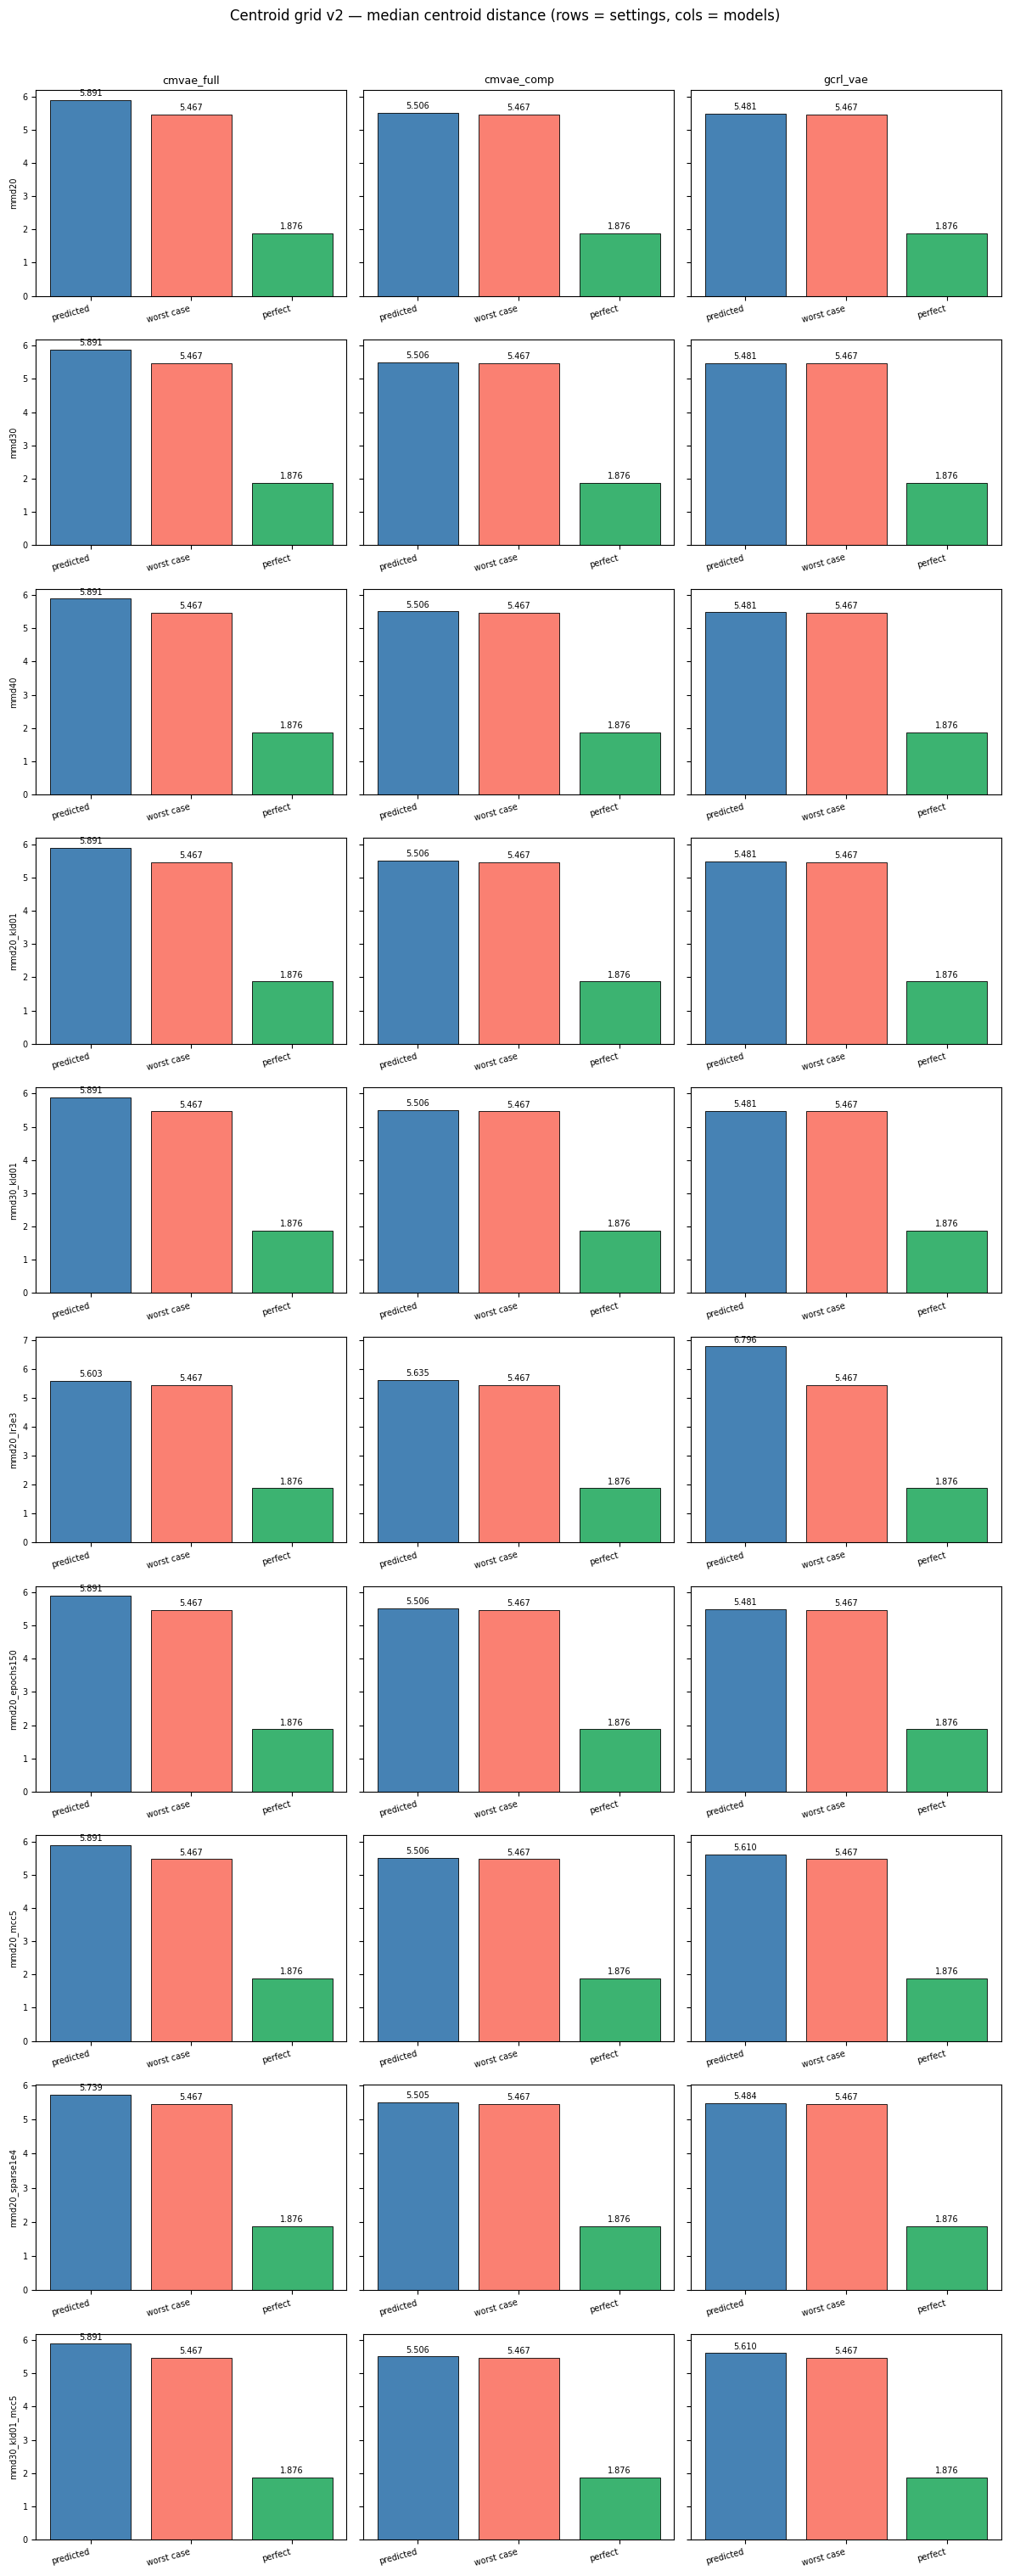

In [11]:
methods_order = ["actual", "worst_case", "perfect_baseline"]
method_colors = {"actual": "steelblue", "worst_case": "salmon", "perfect_baseline": "mediumseagreen"}

cd_df = summary[summary["metric"] == "centroid_distance"]

n_set = len(SETTINGS)
n_sub = len(SUBMODELS)
fig, axes = plt.subplots(n_set, n_sub, figsize=(4 * n_sub, 3 * n_set),
                         sharey="row", squeeze=False)

for row, (name, _) in enumerate(SETTINGS):
    for col, (sub_name, _) in enumerate(SUBMODELS):
        ax = axes[row, col]
        sub_df = cd_df[(cd_df["setting"] == name) & (cd_df["model"] == sub_name)]
        vals = sub_df.set_index("method")["median"].reindex(methods_order)
        bars = ax.bar(
            range(len(methods_order)), vals.values,
            color=[method_colors[m] for m in methods_order],
            edgecolor="k", linewidth=0.6,
        )
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=7)
        ax.set_xticks(range(len(methods_order)))
        ax.set_xticklabels(["predicted", "worst case", "perfect"], rotation=15, ha="right", fontsize=7)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel(name.split("_", 1)[1], fontsize=7)
        if row == 0:
            ax.set_title(sub_name, fontsize=9)

plt.suptitle("Centroid grid v2 — median centroid distance (rows = settings, cols = models)", y=1.01)
plt.tight_layout()
plt.show()